<a href="https://colab.research.google.com/github/Jidnya28/Global-Indian-Financial-Markets-/blob/main/Global_%26_Indian_Financial_Markets_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import kagglehub
muzaddidafaque_global_and_indian_financial_markets_dataset_2025_path = kagglehub.dataset_download('muzaddidafaque/global-and-indian-financial-markets-dataset-2025')

print('Data source import complete.')


100%|██████████| 386k/386k [00:00<00:00, 20.2MB/s]

Extracting files...
Data source import complete.


# 📈 Exploring the Global & Indian Financial Markets Dataset (2010–2025)

This notebook shows how to get started with the  
**Global & Indian Financial Markets Dataset (2010–2025)**.

We will:

- Load the **daily** and **monthly** CSV files
- Do some quick exploratory analysis
- Visualize key trends (NIFTY vs S&P 500, FX, commodities)
- Use the **monthly macro data** to build a simple baseline model:
  - Predict NIFTY 50 monthly return from macroeconomic indicators

---

## 1. Setup & Imports


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## 2. Load the Dataset

In [ ]:


daily_df = pd.read_csv('/content/daily_market_data.csv')
monthly_df = pd.read_csv('/content/monthly_macro_data.csv')



## 3. Quick Data Overview

In [ ]:
print("Daily data shape:", daily_df.shape)
print("Monthly data shape:", monthly_df.shape)

print("\nDaily columns:\n", daily_df.columns.tolist())
print("\nMonthly columns:\n", monthly_df.columns.tolist())

daily_df.info()
monthly_df.info()

Daily data shape: (4172, 26)
Monthly data shape: (192, 15)

Daily columns:
 ['date', 'nifty50_close', 'nifty50_high', 'nifty50_low', 'nifty50_open', 'nifty50_volume', 'sp500_close', 'sp500_high', 'sp500_low', 'sp500_open', 'sp500_volume', 'usd_inr_close', 'usd_inr_high', 'usd_inr_low', 'usd_inr_open', 'usd_inr_volume', 'gold_close', 'gold_high', 'gold_low', 'gold_open', 'gold_volume', 'brent_close', 'brent_high', 'brent_low', 'brent_open', 'brent_volume']

Monthly columns:
 ['date', 'nifty50_close', 'sp500_close', 'gold_close', 'brent_close', 'usd_inr_close', 'nifty50_monthly_return', 'sp500_monthly_return', 'gold_monthly_return', 'brent_monthly_return', 'usd_inr_monthly_change', 'us_cpi_index', 'us_unemployment_rate', 'us_fed_funds_rate', 'us_10y_yield']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4172 entries, 0 to 4171
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4172 non-null   

### Missing Values check

In [ ]:
daily_missing = daily_df.isna().sum().sort_values(ascending=False)
monthly_missing = monthly_df.isna().sum().sort_values(ascending=False)

print("Missing values (daily):\n", daily_missing)
print("\nMissing values (monthly):\n", monthly_missing)

Missing values (daily):
 nifty50_close     244
nifty50_high      244
nifty50_open      244
nifty50_low       244
nifty50_volume    244
brent_close       180
brent_volume      180
brent_open        180
brent_low         180
brent_high        180
gold_low          150
gold_open         150
gold_volume       150
gold_high         150
gold_close        150
sp500_close       149
sp500_high        149
sp500_low         149
sp500_volume      149
sp500_open        149
usd_inr_close       8
usd_inr_open        8
usd_inr_high        8
usd_inr_volume      8
usd_inr_low         8
date                0
dtype: int64

Missing values (monthly):
 nifty50_monthly_return    1
us_unemployment_rate      1
us_cpi_index              1
usd_inr_monthly_change    1
brent_monthly_return      1
gold_monthly_return       1
sp500_monthly_return      1
usd_inr_close             0
brent_close               0
gold_close                0
sp500_close               0
date                      0
nifty50_close             

## 4. Visualizing Key Daily Market Trends
### 4.1 NIFTY 50 vs S&P 500 (Index Levels)

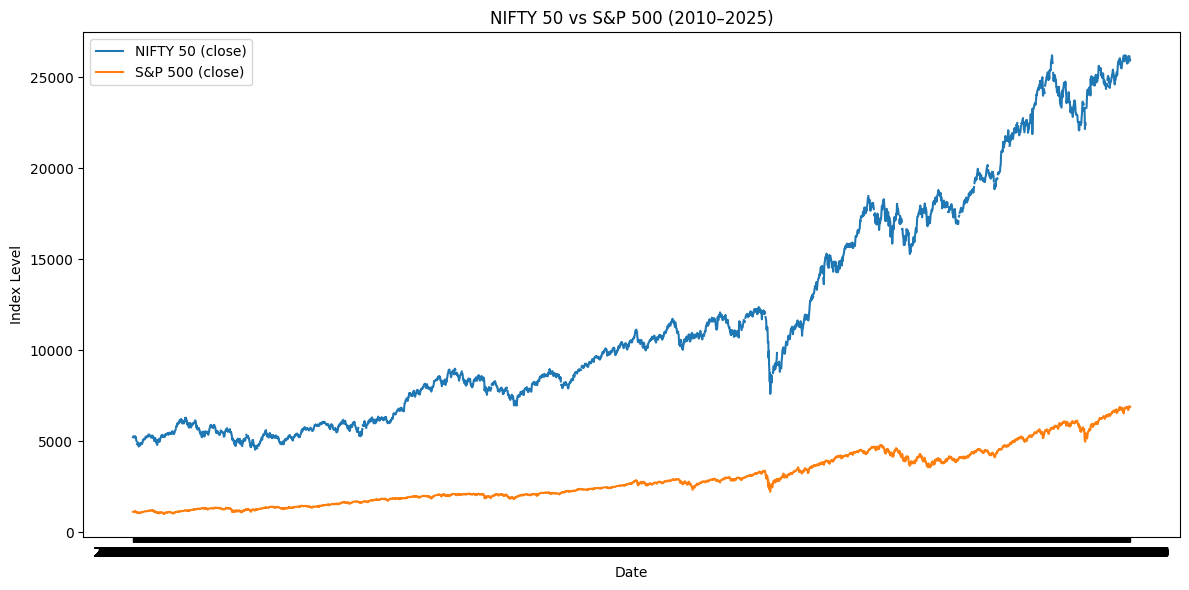

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(daily_df["date"], daily_df["nifty50_close"], label="NIFTY 50 (close)")
plt.plot(daily_df["date"], daily_df["sp500_close"], label="S&P 500 (close)")
plt.title("NIFTY 50 vs S&P 500 (2010–2025)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 USD/INR Exchange Rate

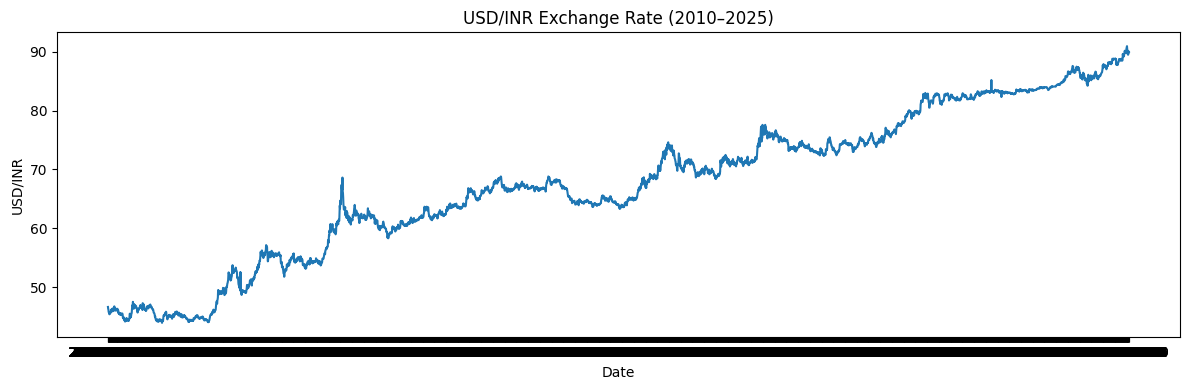

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(daily_df["date"], daily_df["usd_inr_close"])
plt.title("USD/INR Exchange Rate (2010–2025)")
plt.xlabel("Date")
plt.ylabel("USD/INR")
plt.tight_layout()
plt.show()

### 4.3 Gold & Brent Crude Oil

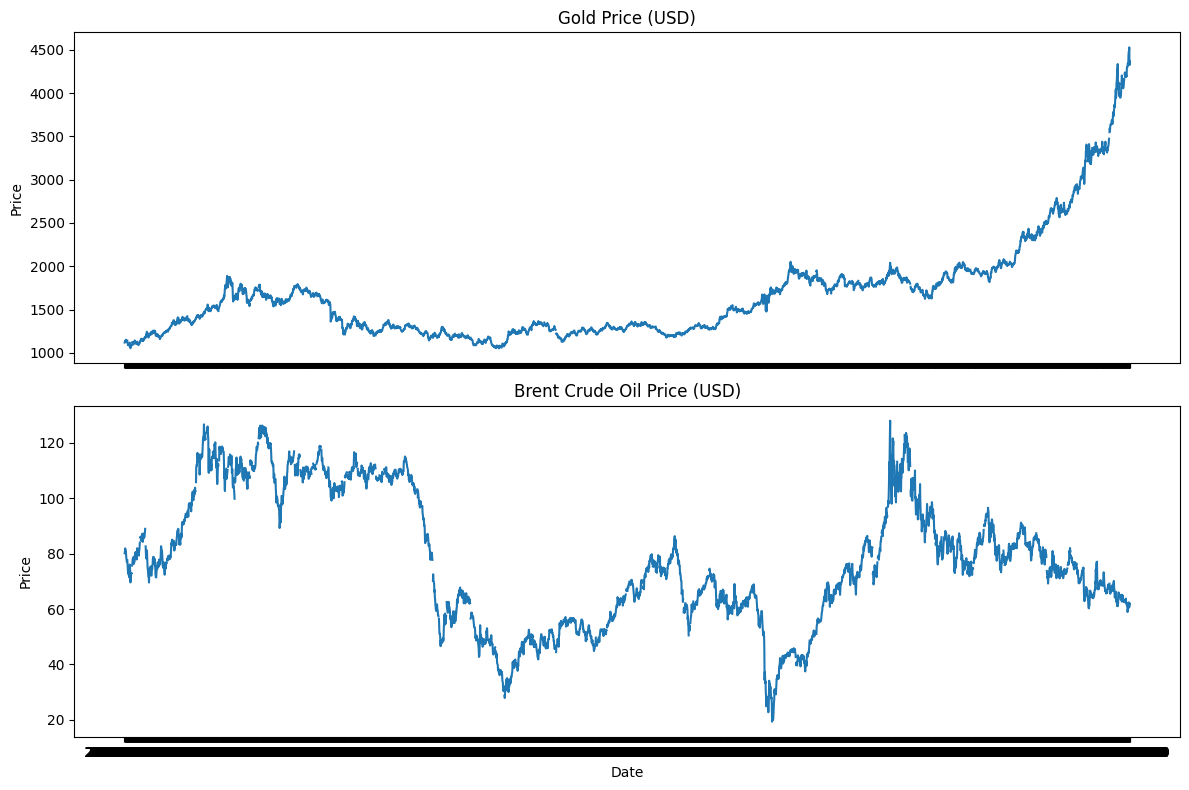

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(daily_df["date"], daily_df["gold_close"])
axes[0].set_title("Gold Price (USD)")

axes[1].plot(daily_df["date"], daily_df["brent_close"])
axes[1].set_title("Brent Crude Oil Price (USD)")

for ax in axes:
    ax.set_ylabel("Price")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 5. Daily Returns & Correlations

Let’s compute simple daily returns and inspect cross-asset correlations.

In [ ]:
returns_df = daily_df.copy()

for col in ["nifty50_close", "sp500_close", "gold_close", "brent_close", "usd_inr_close"]:
    returns_df[f"{col}_ret"] = returns_df[col].ffill().pct_change()

ret_cols = [c for c in returns_df.columns if c.endswith("_ret")]
corr_daily = returns_df[ret_cols].corr()

corr_daily

,nifty50_close_ret,sp500_close_ret,gold_close_ret,brent_close_ret,usd_inr_close_ret
nifty50_close_ret,1.000000,0.262145,0.038743,0.129363,-0.099554
sp500_close_ret,0.262145,1.000000,0.045440,0.294287,-0.000373
gold_close_ret,0.038743,0.045440,1.000000,0.127633,0.003067
brent_close_ret,0.129363,0.294287,0.127633,1.000000,0.003623
usd_inr_close_ret,-0.099554,-0.000373,0.003067,0.003623,1.000000


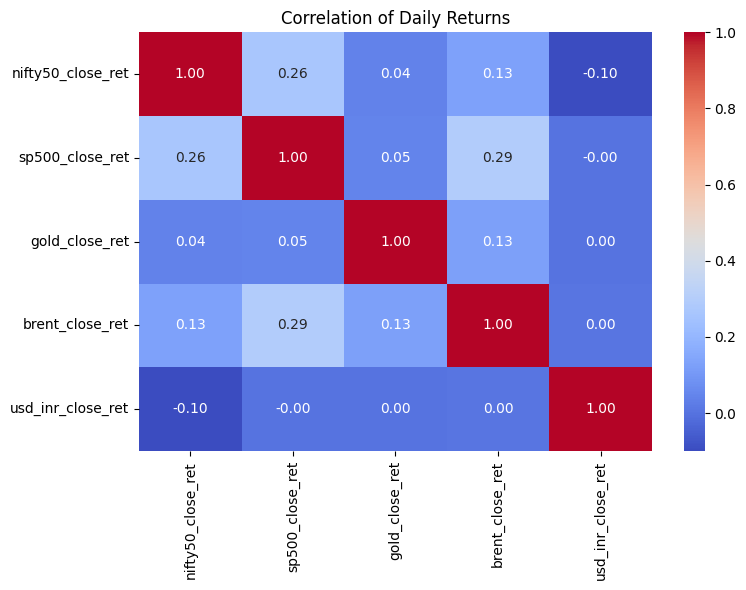

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_daily, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of Daily Returns")
plt.tight_layout()
plt.show()

## 6. Monthly Macro & Market Overview

Now let’s explore the monthly dataset, which contains:

- Monthly closes

- Monthly returns

- Macro indicators (US & India)

In [ ]:
monthly_df.sort_values("date", inplace=True)
monthly_df.head()

,date,nifty50_close,sp500_close,gold_close,brent_close,usd_inr_close,nifty50_monthly_return,sp500_monthly_return,gold_monthly_return,brent_monthly_return,usd_inr_monthly_change,us_cpi_index,us_unemployment_rate,us_fed_funds_rate,us_10y_yield
0,2010-01-01,4882.049805,1073.869995,1083.000000,71.459999,46.098000,NaN,NaN,NaN,NaN,NaN,217.488,9.8,0.11,3.63
1,2010-02-01,4922.299805,1104.489990,1118.300049,77.589996,45.900002,0.008244,0.028514,0.032595,0.085782,-0.004295,217.281,9.8,0.13,3.61
2,2010-03-01,5249.100098,1169.430054,1113.300049,82.699997,44.799999,0.066392,0.058796,-0.004471,0.065859,-0.023965,217.353,9.9,0.16,3.84
3,2010-04-01,5278.000000,1186.689941,1180.099976,87.440002,44.250000,0.005506,0.014759,0.060002,0.057316,-0.012277,217.403,9.9,0.20,3.69
4,2010-05-01,5086.299805,1089.410034,1212.199951,74.019997,46.358002,-0.036321,-0.081976,0.027201,-0.153477,0.047638,217.290,9.6,0.20,3.31


### 6.1 NIFTY vs S&P 500 Monthly Returns

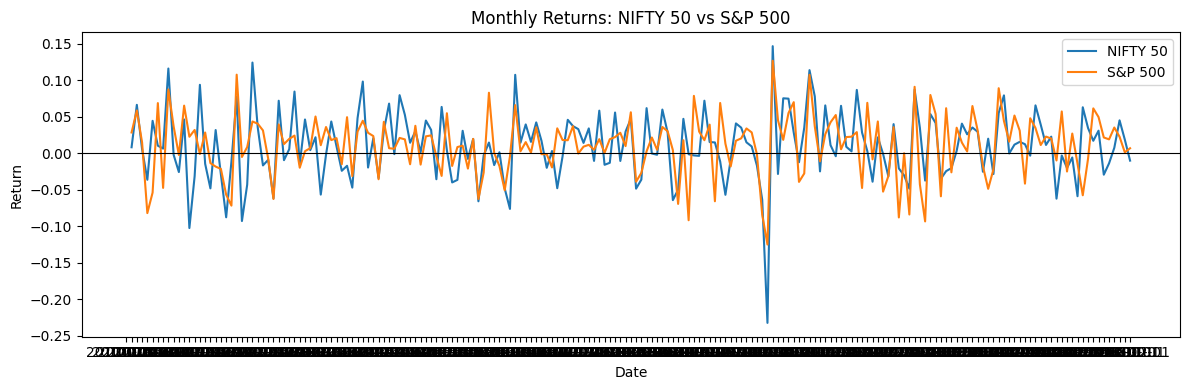

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_df["date"], monthly_df["nifty50_monthly_return"], label="NIFTY 50")
plt.plot(monthly_df["date"], monthly_df["sp500_monthly_return"], label="S&P 500")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Monthly Returns: NIFTY 50 vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 US CPI & Fed Funds Rate

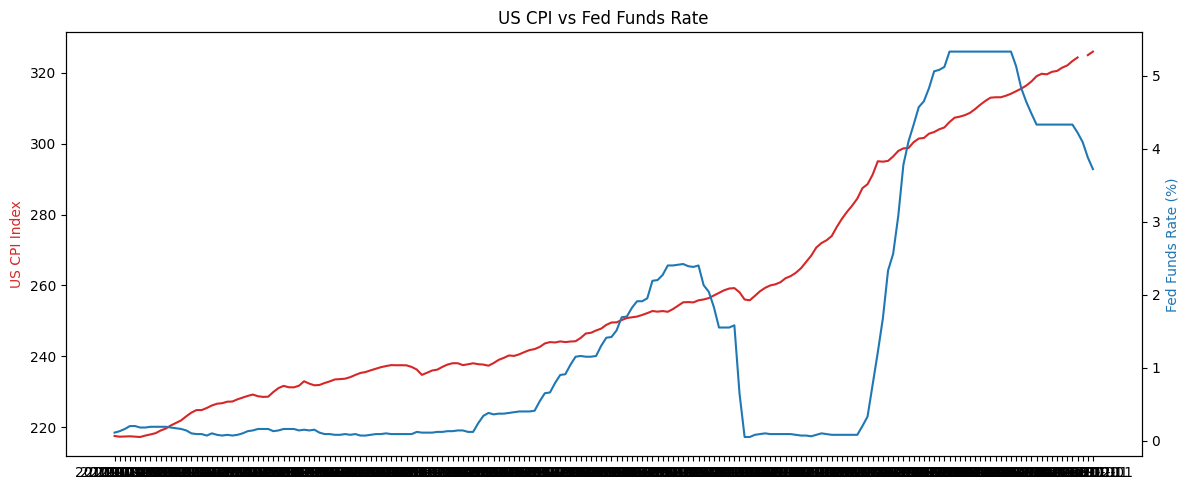

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_df["date"], monthly_df["us_cpi_index"], label="US CPI Index", color="tab:red")
ax1.set_ylabel("US CPI Index", color="tab:red")

ax2 = ax1.twinx()
ax2.plot(monthly_df["date"], monthly_df["us_fed_funds_rate"], label="Fed Funds Rate", color="tab:blue")
ax2.set_ylabel("Fed Funds Rate (%)", color="tab:blue")

plt.title("US CPI vs Fed Funds Rate")
fig.tight_layout()
plt.show()

## 7. Simple Modeling Example: Predict NIFTY 50 Monthly Returns

This is a very basic example to show how you might use the monthly macro features as inputs for a model.

### 7.1 Feature Selection

We will predict `nifty50_monthly_return` using:

- US macro: `us_cpi_index`, `us_unemployment_rate`, `us_fed_funds_rate`, `us_10y_yield`

- Market variables: `sp500_monthly_return`, `gold_monthly_return`, `brent_monthly_return`, `usd_inr_monthly_change`

In [ ]:
model_df = monthly_df.copy()

target_col = "nifty50_monthly_return"

feature_cols = [
    "sp500_monthly_return",
    "gold_monthly_return",
    "brent_monthly_return",
    "usd_inr_monthly_change",
    "us_cpi_index",
    "us_unemployment_rate",
    "us_fed_funds_rate",
    "us_10y_yield"
]

model_df = model_df.dropna(subset=[target_col] + feature_cols)

X = model_df[feature_cols]
y = model_df[target_col]

X.shape, y.shape

((190, 8), (190,))

### 7.2 Train/Test Split and Baseline Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("Baseline Linear Regression Performance:")
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.4f}")


Baseline Linear Regression Performance:
R²:   0.298
RMSE: 0.0293


### 7.3 Plot Actual vs Predicted

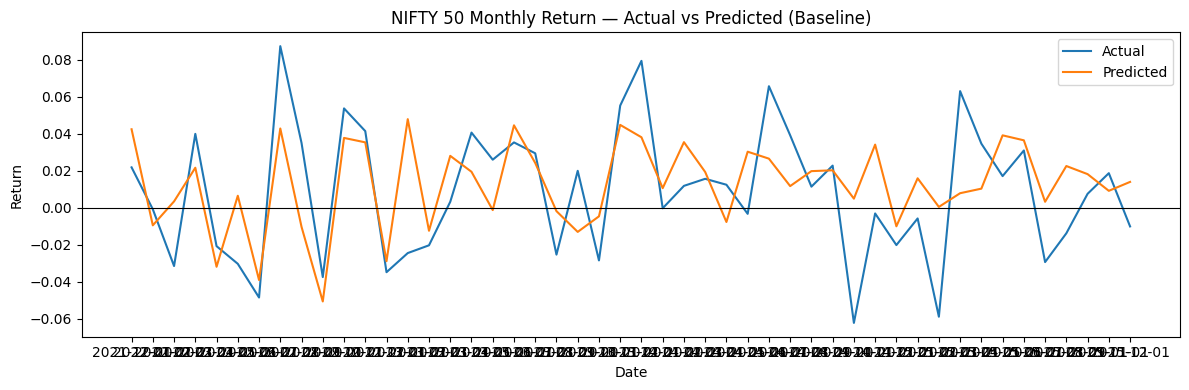

In [ ]:
results = pd.DataFrame({
    "date": model_df["date"].iloc[len(X_train):],
    "actual": y_test.values,
    "predicted": y_pred
})

plt.figure(figsize=(12, 4))
plt.plot(results["date"], results["actual"], label="Actual")
plt.plot(results["date"], results["predicted"], label="Predicted")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("NIFTY 50 Monthly Return — Actual vs Predicted (Baseline)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Next Steps & Ideas

Here are some ideas to extend this notebook:

- Add lagged features (previous month returns, previous CPI, etc.)

- Try Tree-based models (RandomForest, XGBoost, LightGBM)

- Build volatility models using daily returns

- Analyze rolling correlations between markets

- Segment history into regimes (high inflation vs low inflation, etc.)

## Summary

In this notebook, we:

- Loaded the daily and monthly financial datasets

- Explored global vs Indian market trends

- Visualized index levels, FX, commodities, and macro data

- Built a simple baseline model predicting NIFTY 50 monthly returns using macro and market features

- If this dataset or notebook helps your work, please consider upvoting the dataset and forking this notebook 🙌